# Podcast Ad Detection Classifier\n\nCS 6480 Deep Learning — Course Project\n\n**Goal:** Detect advertisement segments in podcast transcripts using three approaches:\n1. Keyword/regex baseline\n2. TF-IDF + Logistic Regression\n3. Fine-tuned DistilBERT\n\n**Training data:** 2,000 LLM-generated synthetic segments (balanced 50/50)\n\n**Test data:** 1,523 real segments from 7 YouTube videos labeled via SponsorBlock (19 ads, 1504 non-ads)

## 1. Setup & Imports

In [ ]:
# Colab: install dependencies & upload data
!pip install -q transformers[torch] accelerate scikit-learn

import os
if not os.path.exists('data'):
    os.makedirs('data', exist_ok=True)
    from google.colab import files
    print('Upload synthetic_train.jsonl and real_test.jsonl')
    uploaded = files.upload()
    for name, content in uploaded.items():
        with open(f'data/{name}', 'wb') as f:
            f.write(content)

In [1]:
import json
import re
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

/Users/stephenhales/School/spring_2026/CS_6480/HW/cs-6480/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0
Device: mps


## 2. Data Loading & Exploration

In [2]:
DATA_DIR = Path("data")

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

synthetic = load_jsonl(DATA_DIR / "synthetic_train.jsonl")
real_test = load_jsonl(DATA_DIR / "real_test.jsonl")

syn_texts = [s["text"] for s in synthetic]
syn_labels = [s["label"] for s in synthetic]
real_texts = [r["text"] for r in real_test]
real_labels = [r["label"] for r in real_test]

print("=== Synthetic Training Data ===")
print(f"  Total: {len(synthetic)}")
print(f"  Ads: {sum(syn_labels)}, Non-ads: {len(syn_labels) - sum(syn_labels)}")
syn_cats = Counter(s["category"] for s in synthetic)
print(f"  Categories: {len(syn_cats)}")
for cat, count in syn_cats.most_common():
    print(f"    {cat}: {count}")

print(f"\n=== Real Test Data ===")
print(f"  Total: {len(real_test)}")
print(f"  Ads: {sum(real_labels)}, Non-ads: {len(real_labels) - sum(real_labels)}")
real_vids = Counter(r["video_id"] for r in real_test)
print(f"  Videos: {len(real_vids)}")
for vid, count in real_vids.items():
    ads = sum(1 for r in real_test if r["video_id"] == vid and r["label"] == 1)
    print(f"    {vid}: {count} segments ({ads} ads)")

=== Synthetic Training Data ===
  Total: 2000
  Ads: 1000, Non-ads: 1000
  Categories: 15
    host_read_ad: 300
    promo_code_ad: 200
    interview: 200
    storytelling: 150
    monologue: 150
    midroll_transition: 150
    banter: 100
    subtle_ad: 100
    news_recap: 100
    preroll_ad: 100
    product_testimonial_ad: 100
    technical_discussion: 100
    intro_outro: 100
    product_mention_organic: 100
    cross_promo: 50

=== Real Test Data ===
  Total: 1523
  Ads: 19, Non-ads: 1504
  Videos: 7
    vif8NQcjVf0: 253 segments (2 ads)
    H9rF1CSSh-w: 519 segments (4 ads)
    1SJiTwbSI58: 287 segments (3 ads)
    KGVpKPNUdzA: 21 segments (1 ads)
    7OLVwZeMCfY: 339 segments (1 ads)
    YSJY3DvnybE: 62 segments (4 ads)
    9szhjhO9epA: 42 segments (4 ads)


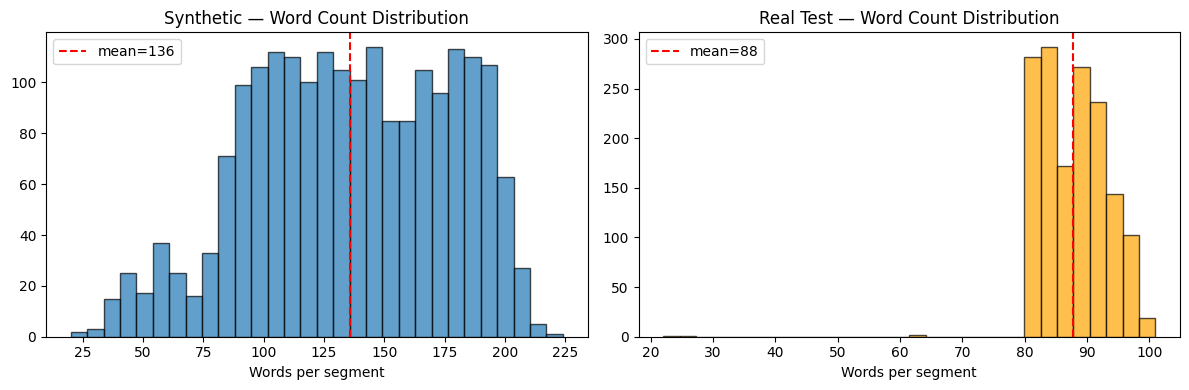

In [3]:
# Text length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

syn_wc = [len(t.split()) for t in syn_texts]
real_wc = [len(t.split()) for t in real_texts]

axes[0].hist(syn_wc, bins=30, alpha=0.7, edgecolor="black")
axes[0].set_title("Synthetic — Word Count Distribution")
axes[0].set_xlabel("Words per segment")
axes[0].axvline(np.mean(syn_wc), color="red", linestyle="--", label=f"mean={np.mean(syn_wc):.0f}")
axes[0].legend()

axes[1].hist(real_wc, bins=30, alpha=0.7, color="orange", edgecolor="black")
axes[1].set_title("Real Test — Word Count Distribution")
axes[1].set_xlabel("Words per segment")
axes[1].axvline(np.mean(real_wc), color="red", linestyle="--", label=f"mean={np.mean(real_wc):.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# Filler word prevalence in synthetic data — a potential domain gap issue
fillers = ["uh", "um", "like", "you know", "honestly", "actually", "basically"]
print("Filler word prevalence in synthetic data:")
for filler in fillers:
    count = sum(1 for t in syn_texts if filler in t.lower())
    print(f"  '{filler}': {count}/{len(syn_texts)} ({count/len(syn_texts)*100:.1f}%)")

print("\nFiller word prevalence in real test data:")
for filler in fillers:
    count = sum(1 for t in real_texts if filler in t.lower())
    print(f"  '{filler}': {count}/{len(real_texts)} ({count/len(real_texts)*100:.1f}%)")

Filler word prevalence in synthetic data:
  'uh': 1010/2000 (50.5%)
  'um': 1080/2000 (54.0%)
  'like': 1333/2000 (66.6%)
  'you know': 998/2000 (49.9%)
  'honestly': 1269/2000 (63.4%)
  'actually': 1382/2000 (69.1%)
  'basically': 966/2000 (48.3%)

Filler word prevalence in real test data:
  'uh': 24/1523 (1.6%)
  'um': 338/1523 (22.2%)
  'like': 898/1523 (59.0%)
  'you know': 409/1523 (26.9%)
  'honestly': 4/1523 (0.3%)
  'actually': 175/1523 (11.5%)
  'basically': 65/1523 (4.3%)


In [5]:
# Example segments
print("=== Example Synthetic Ad ===")
ad_ex = next(s for s in synthetic if s["label"] == 1)
print(f"  Category: {ad_ex['category']}")
print(f"  Text: {ad_ex['text'][:300]}...")

print("\n=== Example Synthetic Non-Ad ===")
nonad_ex = next(s for s in synthetic if s["label"] == 0)
print(f"  Category: {nonad_ex['category']}")
print(f"  Text: {nonad_ex['text'][:300]}...")

print("\n=== Example Real Ad ===")
real_ad = next(r for r in real_test if r["label"] == 1)
print(f"  Video: {real_ad['video_id']}")
print(f"  Text: {real_ad['text'][:300]}...")

print("\n=== Example Real Non-Ad ===")
real_nonad = next(r for r in real_test if r["label"] == 0)
print(f"  Video: {real_nonad['video_id']}")
print(f"  Text: {real_nonad['text'][:300]}...")

=== Example Synthetic Ad ===
  Category: promo_code_ad
  Text: If you've been thinking about trying SwiftShip Delivery now is the time They're running a honestly special where you use code SHIP look at checkout and get thirty percent off. Which again I know look is kind of a hot take but whatever. That's so swiftship.com code SHIP. We'll have the link in the de...

=== Example Synthetic Non-Ad ===
  Category: interview
  Text: i want look to go back basically to something you said earlier about space you know exploration And that is coming from someone who has been basically doing right this for a while. You mentioned that there was this moment where everything kind of clicked for you. And I think that is worth sitting wi...

=== Example Real Ad ===
  Video: vif8NQcjVf0
  Text: And in the meantime, my, my favorite answer is eliminate waste. You know, we've, we've got all that idle power. I want to evacuate it as fast as possible. Yeah, there, there's a lot of low hanging fruit here on 

## 3. Preprocessing\n\nThe synthetic data generator injected filler words ("honestly", "actually", "like", etc.) into 50-70% of segments across both classes. This could create a spurious shortcut for the model.\n\nWe prepare **two versions** of the data — raw and cleaned — and train each model on both to empirically measure whether filler removal helps generalization to real data.

In [6]:
FILLER_PATTERN = re.compile(
    r"\b(honestly|actually|basically|like|look|right|um|uh|well|you know)\b",
    re.IGNORECASE,
)

def clean_text(text):
    text = text.lower().strip()
    text = FILLER_PATTERN.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Prepare raw and cleaned versions
syn_texts_raw = syn_texts
syn_texts_clean = [clean_text(t) for t in syn_texts]
real_texts_raw = real_texts
real_texts_clean = [clean_text(t) for t in real_texts]

# Train/val split — same indices for both versions
train_idx, val_idx = train_test_split(
    range(len(syn_texts)), test_size=0.2, stratify=syn_labels, random_state=42
)

train_texts_raw = [syn_texts_raw[i] for i in train_idx]
train_texts_clean = [syn_texts_clean[i] for i in train_idx]
train_labels = [syn_labels[i] for i in train_idx]

val_texts_raw = [syn_texts_raw[i] for i in val_idx]
val_texts_clean = [syn_texts_clean[i] for i in val_idx]
val_labels = [syn_labels[i] for i in val_idx]

print(f"Train: {len(train_labels)} ({sum(train_labels)} ads)")
print(f"Val:   {len(val_labels)} ({sum(val_labels)} ads)")
print(f"Test:  {len(real_labels)} ({sum(real_labels)} ads)")

# Show cleaning effect
print(f"\nExample cleaning:")
print(f"  Raw:     {syn_texts_raw[0][:150]}...")
print(f"  Cleaned: {syn_texts_clean[0][:150]}...")

Train: 1600 (800 ads)
Val:   400 (200 ads)
Test:  1523 (19 ads)

Example cleaning:
  Raw:     If you've been thinking about trying SwiftShip Delivery now is the time They're running a honestly special where you use code SHIP look at checkout an...
  Cleaned: if you've been thinking about trying swiftship delivery now is the time they're running a special where you use code ship at checkout and get thirty p...


In [7]:
# Shared evaluation helper
all_results = []

def evaluate(y_true, y_pred, model_name, dataset_name, verbose=True):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    result = {
        "Model": model_name, "Dataset": dataset_name,
        "Accuracy": acc, "Precision": p, "Recall": r, "F1": f1,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }
    all_results.append(result)
    if verbose:
        print(f"\n{model_name} on {dataset_name}:")
        print(f"  Accuracy={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}")
        print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    return result

## 4. Model 1 — Keyword/Regex Baseline\n\nA simple pattern matcher that predicts "ad" if the text contains any common ad-related phrases. This provides an interpretable lower bound.

In [8]:
AD_PATTERNS = [
    re.compile(p, re.IGNORECASE) for p in [
        r"sponsor(ed|s)?\s+by",
        r"promo\s*code",
        r"use\s+code\s+\w+",
        r"brought\s+to\s+you\s+by",
        r"percent\s+off",
        r"\d+%\s+off",
        r"free\s+trial",
        r"\.com\s*(slash|\/)\s*\w+",
        r"thank\s+(you\s+)?to\s+(our\s+)?sponsors?",
        r"link\s+in\s+the\s+description",
        r"discount\s+(code|on)",
        r"check\s+(them\s+)?out\s+at\s+\w+",
        r"sign\s+up\s+(at|with)",
        r"go\s+to\s+\w+\.\w+",
        r"special\s+offer",
        r"limited\s+time",
        r"(first|next)\s+\d+\s+(order|month|purchase)",
    ]
]

def keyword_predict(text):
    for pattern in AD_PATTERNS:
        if pattern.search(text):
            return 1
    return 0

# Evaluate on validation and real test (raw text — regex is content-based)
kw_val_preds = [keyword_predict(t) for t in val_texts_raw]
kw_real_preds = [keyword_predict(t) for t in real_texts_raw]

evaluate(val_labels, kw_val_preds, "Keyword", "Validation")
evaluate(real_labels, kw_real_preds, "Keyword", "Real Test")


Keyword on Validation:
  Accuracy=0.848  Precision=0.979  Recall=0.710  F1=0.823
  TP=142  FP=3  FN=58  TN=197

Keyword on Real Test:
  Accuracy=0.993  Precision=0.900  Recall=0.474  F1=0.621
  TP=9  FP=1  FN=10  TN=1503


{'Model': 'Keyword',
 'Dataset': 'Real Test',
 'Accuracy': np.float64(0.9927774130006566),
 'Precision': 0.9,
 'Recall': 0.47368421052631576,
 'F1': 0.6206896551724138,
 'TP': np.int64(9),
 'FP': np.int64(1),
 'FN': np.int64(10),
 'TN': np.int64(1503)}

## 5. Model 2 — TF-IDF + Logistic Regression\n\nA statistical baseline using TF-IDF features with bigrams. Trained on both raw and cleaned text to measure the effect of filler removal.

In [9]:
def train_tfidf_lr(train_texts, val_texts, real_texts, train_labels, val_labels, real_labels, label):
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
    X_train = tfidf.fit_transform(train_texts)
    X_val = tfidf.transform(val_texts)
    X_real = tfidf.transform(real_texts)

    lr = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0, random_state=42)
    lr.fit(X_train, train_labels)

    val_preds = lr.predict(X_val)
    real_preds = lr.predict(X_real)

    evaluate(val_labels, val_preds.tolist(), f"TF-IDF+LR ({label})", "Validation")
    evaluate(real_labels, real_preds.tolist(), f"TF-IDF+LR ({label})", "Real Test")

    return tfidf, lr, real_preds

# Train on raw text
print("=" * 50)
print("TF-IDF + LR on RAW text")
print("=" * 50)
tfidf_raw, lr_raw, lr_raw_real_preds = train_tfidf_lr(
    train_texts_raw, val_texts_raw, real_texts_raw,
    train_labels, val_labels, real_labels, "raw"
)

# Train on cleaned text
print("\n" + "=" * 50)
print("TF-IDF + LR on CLEANED text")
print("=" * 50)
tfidf_clean, lr_clean, lr_clean_real_preds = train_tfidf_lr(
    train_texts_clean, val_texts_clean, real_texts_clean,
    train_labels, val_labels, real_labels, "clean"
)

TF-IDF + LR on RAW text

TF-IDF+LR (raw) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=200

TF-IDF+LR (raw) on Real Test:
  Accuracy=0.989  Precision=0.600  Recall=0.316  F1=0.414
  TP=6  FP=4  FN=13  TN=1500

TF-IDF + LR on CLEANED text

TF-IDF+LR (clean) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=200

TF-IDF+LR (clean) on Real Test:
  Accuracy=0.989  Precision=0.667  Recall=0.316  F1=0.429
  TP=6  FP=3  FN=13  TN=1501


In [10]:
# Top features for each class (cleaned model)
feature_names = tfidf_clean.get_feature_names_out()
coefs = lr_clean.coef_[0]
top_ad = np.argsort(coefs)[-20:][::-1]
top_nonad = np.argsort(coefs)[:20]

print("Top 20 features — AD class (cleaned model):")
for i in top_ad:
    print(f"  {feature_names[i]:30s} coef={coefs[i]:.3f}")

print("\nTop 20 features — NON-AD class (cleaned model):")
for i in top_nonad:
    print(f"  {feature_names[i]:30s} coef={coefs[i]:.3f}")

Top 20 features — AD class (cleaned model):
  code                           coef=2.608
  com                            coef=2.266
  use                            coef=2.027
  co                             coef=1.834
  use code                       coef=1.572
  quick                          coef=1.562
  slash                          coef=1.534
  them                           coef=1.463
  go to                          coef=1.435
  notes                          coef=1.355
  out                            coef=1.324
  link                           coef=1.321
  check                          coef=1.248
  percent                        coef=1.238
  now                            coef=1.232
  and use                        coef=1.231
  go                             coef=1.220
  link in                        coef=1.153
  codeforge                      coef=1.153
  groundup                       coef=1.153

Top 20 features — NON-AD class (cleaned model):
  what                     

## 6. Model 3 — Fine-tuned DistilBERT (Primary Model)\n\nDistilBERT is a distilled version of BERT with 66M parameters (vs BERT's 110M), roughly 60% faster on CPU while retaining ~97% of BERT's performance.\n\nWe use `max_length=128` tokens — the real test data averages ~88 words which fits well. Some synthetic segments may be truncated, but ad signals tend to appear early in the segment.\n\nTrained on both raw and cleaned text for comparison.

In [11]:
class AdDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    acc = np.mean(preds == labels)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

In [12]:
MODEL_NAME = "distilbert-base-uncased"

def train_distilbert(train_texts, val_texts, real_texts, train_labels, val_labels, real_labels, label):
    """Fine-tune DistilBERT and return predictions on all datasets."""
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    train_dataset = AdDataset(train_texts, train_labels, tokenizer)
    val_dataset = AdDataset(val_texts, val_labels, tokenizer)
    real_dataset = AdDataset(real_texts, real_labels, tokenizer)

    training_args = TrainingArguments(
        output_dir=f"./results/distilbert_{label}",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        use_cpu=DEVICE == "cpu",
        fp16=DEVICE == "cuda",
        report_to="none",
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    print(f"Training DistilBERT ({label})...")
    trainer.train()

    # Predictions
    val_preds = np.argmax(trainer.predict(val_dataset).predictions, axis=-1)
    real_preds = np.argmax(trainer.predict(real_dataset).predictions, axis=-1)

    evaluate(val_labels, val_preds.tolist(), f"DistilBERT ({label})", "Validation")
    evaluate(real_labels, real_preds.tolist(), f"DistilBERT ({label})", "Real Test")

    return trainer, real_preds

In [13]:
# Train on raw text
trainer_raw, bert_raw_real_preds = train_distilbert(
    train_texts_raw, val_texts_raw, real_texts_raw,
    train_labels, val_labels, real_labels, "raw"
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 18758.91it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=1.1.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=1.1.0'`

In [ ]:
# Train on cleaned text
trainer_clean, bert_clean_real_preds = train_distilbert(
    train_texts_clean, val_texts_clean, real_texts_clean,
    train_labels, val_labels, real_labels, "clean"
)

## 7. Comparison & Evaluation\n\nWith only 19 real ad segments out of 1,523 total (1.2%), accuracy is misleading — a model predicting all non-ad gets 98.8%. We focus on **precision, recall, and F1** as the meaningful metrics.\n\nPer the project proposal, recall is weighted more heavily: missing an ad is less disruptive than incorrectly flagging real content.

In [ ]:
# Comparison table
print(f"{'Model':<25} {'Dataset':<12} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'TP':>4} {'FP':>4} {'FN':>4} {'TN':>5}")
print("-" * 95)
for r in all_results:
    print(f"{r['Model']:<25} {r['Dataset']:<12} {r['Accuracy']:>6.3f} {r['Precision']:>6.3f} {r['Recall']:>6.3f} {r['F1']:>6.3f} {r['TP']:>4} {r['FP']:>4} {r['FN']:>4} {r['TN']:>5}")

In [ ]:
# Confusion matrices for real test set (all 5 model variants)
real_test_results = [r for r in all_results if r["Dataset"] == "Real Test"]
n_models = len(real_test_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, r in zip(axes, real_test_results):
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Ad", "Ad"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(r["Model"], fontsize=10)

plt.suptitle("Confusion Matrices — Real Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Bar chart comparing F1 and Recall on real test set
real_models = [r["Model"] for r in real_test_results]
real_f1 = [r["F1"] for r in real_test_results]
real_recall = [r["Recall"] for r in real_test_results]

x = np.arange(len(real_models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, real_f1, width, label="F1", color="steelblue")
ax.bar(x + width/2, real_recall, width, label="Recall", color="coral")
ax.set_ylabel("Score")
ax.set_title("F1 and Recall on Real Test Set")
ax.set_xticks(x)
ax.set_xticklabels(real_models, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Error Analysis\n\nWith only 19 real ad segments, we can inspect every false negative (missed ad) and false positive (incorrectly flagged non-ad) to understand model behavior.

In [ ]:
# Collect all real test predictions into a dict for analysis
model_preds = {
    "Keyword": kw_real_preds,
    "TF-IDF+LR (raw)": lr_raw_real_preds.tolist(),
    "TF-IDF+LR (clean)": lr_clean_real_preds.tolist(),
    "DistilBERT (raw)": bert_raw_real_preds.tolist(),
    "DistilBERT (clean)": bert_clean_real_preds.tolist(),
}

# False negatives — which real ads did each model miss?
print("=== False Negatives (Missed Ads) ===\n")
ad_indices = [i for i, l in enumerate(real_labels) if l == 1]
for idx in ad_indices:
    text_preview = real_texts[idx][:120]
    vid = real_test[idx]["video_id"]
    missed_by = [name for name, preds in model_preds.items() if preds[idx] == 0]
    caught_by = [name for name, preds in model_preds.items() if preds[idx] == 1]
    print(f"Segment {idx} ({vid}):")
    print(f"  \"{text_preview}...\"")
    print(f"  Caught by: {caught_by if caught_by else 'NONE'}")
    print(f"  Missed by: {missed_by if missed_by else 'NONE'}")
    print()

In [ ]:
# False positives — sample of non-ad segments incorrectly flagged (best model)
# Use the model with fewest FP on real test as reference
best_model = min(real_test_results, key=lambda r: r["FP"] if r["FP"] > 0 else float("inf"))
best_name = best_model["Model"]
best_preds = model_preds[best_name]

fp_indices = [i for i in range(len(real_labels)) if real_labels[i] == 0 and best_preds[i] == 1]
print(f"=== False Positives for {best_name} ({len(fp_indices)} total) ===\n")
for idx in fp_indices[:10]:  # show up to 10
    text_preview = real_texts[idx][:150]
    vid = real_test[idx]["video_id"]
    print(f"Segment {idx} ({vid}):")
    print(f"  \"{text_preview}...\"")
    print()

In [ ]:
# Per-video recall breakdown (best DistilBERT model)
print("=== Per-Video Recall Breakdown ===\n")
for name, preds in model_preds.items():
    print(f"{name}:")
    for vid in sorted(set(r["video_id"] for r in real_test)):
        vid_mask = [i for i, r in enumerate(real_test) if r["video_id"] == vid]
        vid_ads = [i for i in vid_mask if real_labels[i] == 1]
        if not vid_ads:
            continue
        caught = sum(1 for i in vid_ads if preds[i] == 1)
        print(f"  {vid}: {caught}/{len(vid_ads)} ads detected")
    print()

## 9. Conclusion\n\n### Findings\n\n- **Three approaches** were compared: keyword/regex baseline, TF-IDF + logistic regression, and fine-tuned DistilBERT\n- Each learning-based model was trained on both **raw and filler-cleaned** synthetic data to measure the effect of preprocessing\n- The **synthetic-to-real domain gap** is the central challenge — synthetic data uses fictional brands and formulaic structures, while real ads are messier and more varied\n\n### Limitations\n\n- **Small real test set**: Only 19 ad segments across 7 videos — each missed ad changes recall by ~5 percentage points\n- **Synthetic training data**: LLM-generated text is cleaner and more uniform than real Whisper transcriptions\n- **CPU training**: Limited to DistilBERT (66M params) rather than larger models\n- **Text-only**: No audio features used (mel spectrograms were a stretch goal)\n\n### Future Work\n\n- Collect more real labeled data from SponsorBlock to build a larger, more diverse test set\n- Fine-tune on a mix of synthetic + real data (semi-supervised approach)\n- Explore audio-based CNN classifier on mel spectrograms for comparison\n- Threshold tuning to trade precision for recall with a larger test set\n- Investigate longer context windows to capture segment-level patterns